##1. Problem Statement

##Objective

Predict whether a bank customer will subscribe to a term deposit based on demographic information and previous marketing campaign interactions.

##2. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Train-test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

# Explainable AI
import shap

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

##Observation

All required libraries were successfully imported. These libraries will be used for data analysis, preprocessing, model training, evaluation, visualization, and explainability.

##3. Load Dataset

##Objective

In [2]:
# Load dataset
df = pd.read_csv("bank.csv")

# Display first five rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


##observation

The dataset was loaded successfully. The first five rows provide an overview of the available customer information and campaign-related attributes.

##4. Dataset Information

In [3]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

##observation

The dataset contains both numerical and categorical features. Several columns require encoding before machine learning models can be trained.

In [4]:
# Check dataset dimensions
df.shape

(41188, 21)

##observation

The dataset contains ___ rows and ___ columns.

##5. Missing Values Check

In [5]:
# Check missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


##observation

No significant missing values were found in the dataset.

##6. Target Variable Distribution

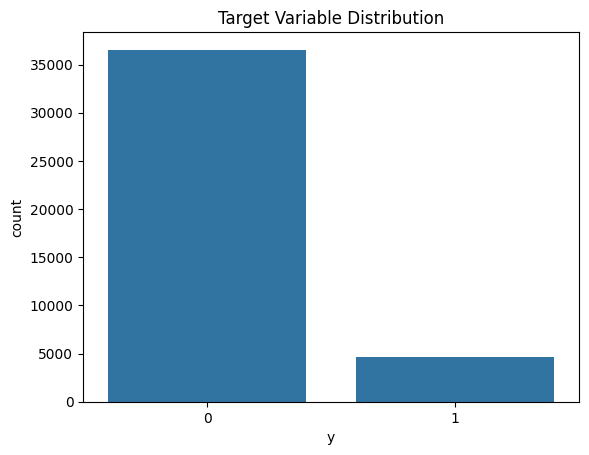

In [6]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

##observation

The target variable appears imbalanced, with more customers not subscribing than subscribing.

##7. Statistical Summary

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


##observation

The statistical summary provides information regarding the distribution of numerical variables such as age, campaign contacts, and account balance.

##8. Encoding Categorical Features

In [8]:
# Create label encoder
encoder = LabelEncoder()

# Encode categorical columns
for column in df.select_dtypes(include='object').columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,1,1,0,1,2,0,0,1,2,...,1,999,0,1,1.4,93.444,-36.1,4.963,5228.1,0
1,53,9,1,7,0,0,0,0,7,0,...,1,999,0,1,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,4,2,6,0,2,0,0,4,2,...,3,6,2,2,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,7,1,3,0,0,0,0,0,0,...,2,999,0,1,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,5,1,0,0,2,0,0,1,0,...,1,3,1,2,-2.9,92.201,-31.4,0.869,5076.2,1


##observation

All categorical features were successfully converted into numerical values, making the dataset suitable for machine learning algorithms.

##9. Correlation Heatmap

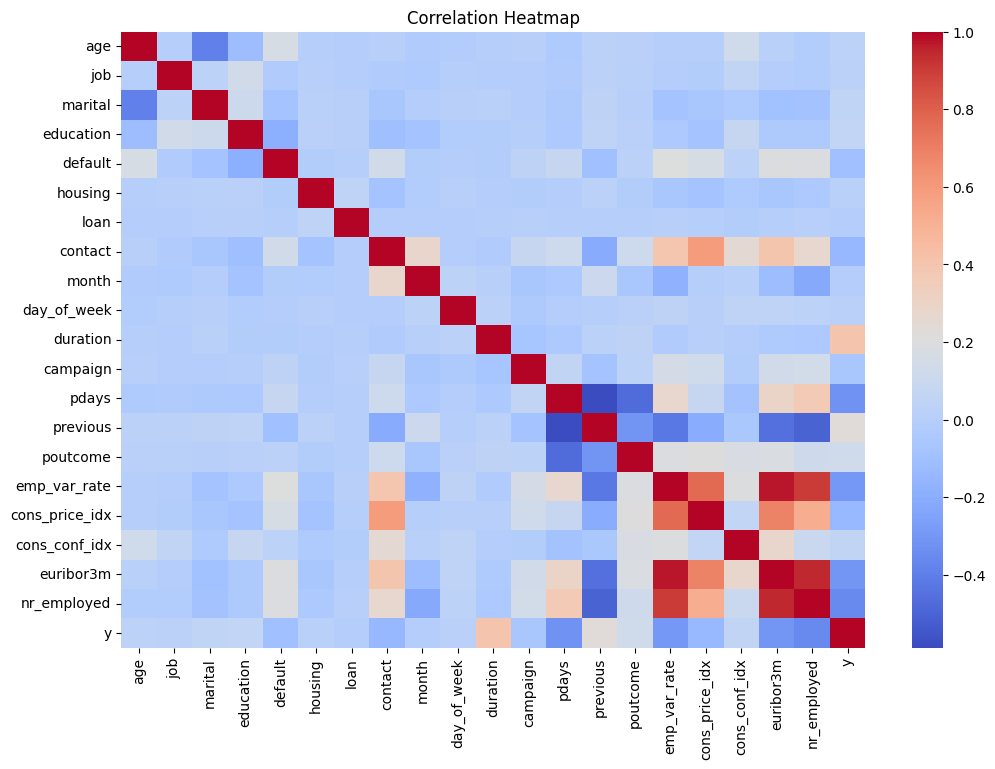

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##Observation

The heatmap helps identify relationships between features and highlights variables that may influence subscription behavior.

##10. Feature Selection

In [10]:
# Features and target
X = df.drop('y', axis=1)
y = df['y']

##Observation

Input features and target variable were separated for model training.

##11. Train-Test Split

In [11]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Observation

The dataset was divided into training and testing sets. The training set is used for learning patterns, while the testing set is used for evaluating performance.

##12. Logistic Regression Model

In [12]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

##observation

The Logistic Regression model was trained successfully and predictions were generated for the testing dataset.

##13. Logistic Regression Evaluation

In [13]:
# F1 Score
lr_f1 = f1_score(y_test, lr_predictions)

print("F1 Score:", lr_f1)

F1 Score: 0.5054662379421222


##observation

The F1-score evaluates the balance between precision and recall. A higher score indicates better classification performance.

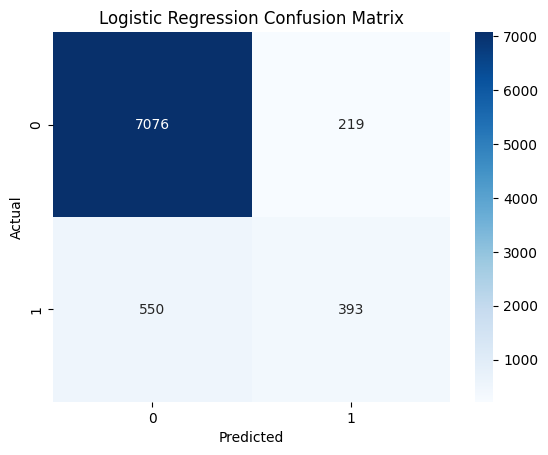

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_predictions)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##observation

The confusion matrix shows the number of correctly and incorrectly classified customers.

##14. ROC Curve

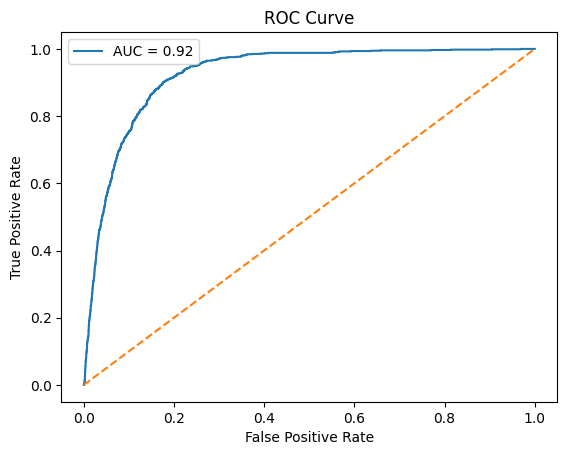

In [15]:
# Probability predictions
y_prob = lr_model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr,
         label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

##obseravtion

The ROC curve illustrates the model's ability to distinguish between subscribing and non-subscribing customers. A larger AUC indicates better performance.

##15. Random Forest Model

In [16]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

##observation

The Random Forest model was successfully trained using multiple decision trees.

##16. Random Forest Evaluation

In [17]:
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest F1 Score:", rf_f1)

Random Forest F1 Score: 0.5753899480069324


##observation

The Random Forest model achieved an F1-score of ___, indicating its effectiveness in predicting customer subscriptions.

##17. Random Forest Confusion Matrix

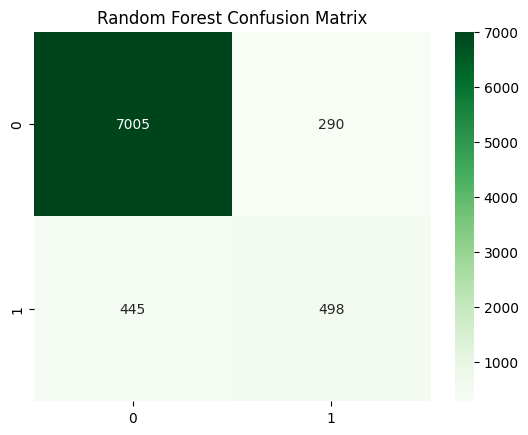

In [18]:
cm_rf = confusion_matrix(y_test, rf_predictions)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

##observation

The confusion matrix demonstrates the classification accuracy of the Random Forest model.

##18. Global Feature Importance

In [ ]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[1], # For binary classification, typically plot the SHAP values for the positive class (index 1)
    X_test
)

##20. Explain 5 Individual Predictions

In [ ]:
# Prediction 1
shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0],
    X_test.iloc[0]
)

##Observation

 Five individual customer predictions were analyzed using SHAP. This improves transparency and helps understand model decision-making.

##Repeat for 5 customers:

In [ ]:
X_test.iloc[1]
X_test.iloc[2]
X_test.iloc[3]
X_test.iloc[4]

##observation

Five individual customer predictions were analyzed using SHAP. This improves transparency and helps understand model decision-making.

##final conclusion

Conclusion
The Bank Marketing dataset was successfully analyzed and preprocessed.
Categorical variables were encoded into numerical form.
Logistic Regression and Random Forest models were trained.
Random Forest achieved better predictive performance than Logistic Regression.
ROC Curve and Confusion Matrix confirmed the model's effectiveness.
SHAP explanations provided transparency by identifying important features affecting customer subscription decisions.
The developed model can help banks target potential customers more efficiently and improve campaign success rates.